## Ali Abdullah Ahmad   
## CWID - 20031246

In [35]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split


In [36]:
#Importing Trained data from hw3
df_train = pd.read_csv('D:/Stevens GIT/Stevens_IT-MS_in_CS/SPRING_25/CS559_Applications_of_ML/HW/hw3/train_data_processed.csv')
df_test = pd.read_csv('D:/Stevens GIT/Stevens_IT-MS_in_CS/SPRING_25/CS559_Applications_of_ML/HW/hw3/train_data_processed.csv')

X_train = df_train.drop(columns=['Salary'])
y_train = df_train['Salary']
X_test = df_test.drop(columns=['Salary'])
y_test = df_test['Salary']

In [37]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((257, 13), (257, 13), (257,), (257,))

In [38]:
#Normalise
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## [60 points, 15 points each model] Model training


In [39]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.kernel_ridge import KernelRidge
from sklearn.svm import SVR
import time as time
from sklearn.metrics import mean_squared_error,accuracy_score, r2_score 

In [41]:
models = {
    "NeuralNet":MLPRegressor(max_iter = 200000, solver = 'adam',learning_rate_init = 0.01, learning_rate = 'constant', random_state=42),
    "KNN":KNeighborsRegressor(n_neighbors=5),
    "KernelRidge":KernelRidge(alpha=1.0,kernel='rbf'),
    "SVM":SVR(kernel='rbf',C=1.0, gamma='scale')
}

results={}

for name , model in models.items():
    start_time = time.time()
    model.fit(X_train_scaled, y_train)
    training_time = time.time() - start_time

    y_pred_train = model.predict(X_train_scaled)
    y_pred_test = model.predict(X_test_scaled)

    train_mse =  mean_squared_error(y_train,y_pred_train)
    test_mse =  mean_squared_error(y_test,y_pred_test)

    train_r2 = model.score(X_train_scaled, y_train)
    test_r2 = model.score(X_test_scaled, y_test)

    result = {
        "Model": name,
        "Training Time": training_time,
        "Training R2 Score": train_r2,
        "Testing R2 Score": test_r2,
        "Train MSE": train_mse,
        "Test MSE": test_mse
    }
    results[name] = result


# Convert the results dictionary to a DataFrame for better visualization
results_df = pd.DataFrame.from_dict(results, orient='index')

# Display the DataFrame
results_df

,Model,Training Time,Training R2 Score,Testing R2 Score,Train MSE,Test MSE
NeuralNet,NeuralNet,2.006815,0.853175,0.853175,23400.342864,23400.342864
KNN,KNN,0.000518,0.532197,0.532197,74556.305073,74556.305073
KernelRidge,KernelRidge,0.003002,0.702914,0.702914,47348.271034,47348.271034
SVM,SVM,0.004001,0.019557,0.019557,156258.576311,156258.576311


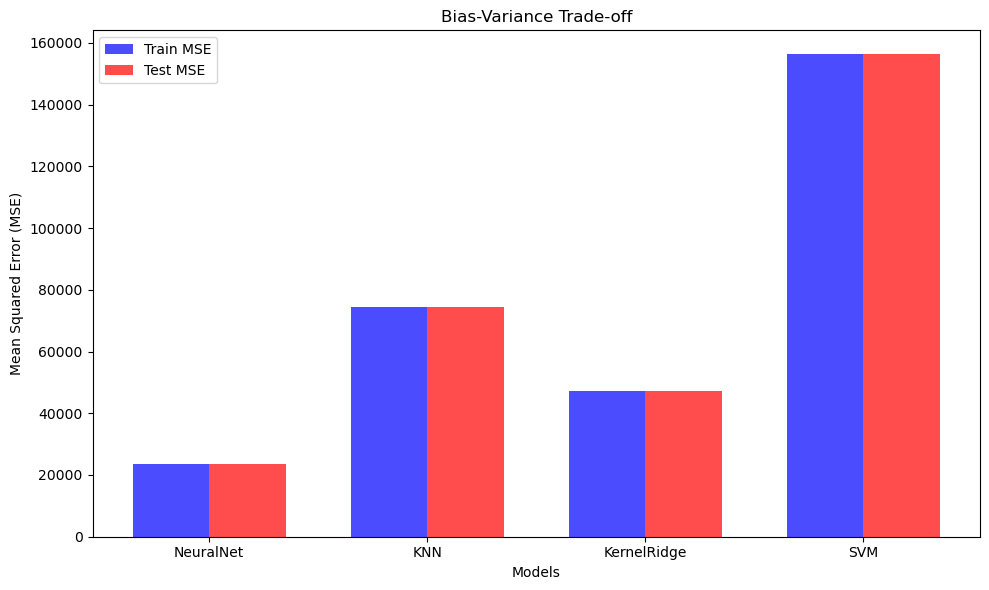

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

# Extract values from results
models = list(results.keys())
train_mse = [results[model]["Train MSE"] for model in models]
test_mse = [results[model]["Test MSE"] for model in models]

# Plotting the results
plt.figure(figsize=(10, 6))
bar_width = 0.35  # Width of the bars
x_indices = np.arange(len(models))  # X-axis positions for the bars

# Plot train and test MSE side by side
plt.bar(x_indices - bar_width / 2, train_mse, bar_width, label="Train MSE", alpha=0.7, color='blue')
plt.bar(x_indices + bar_width / 2, test_mse, bar_width, label="Test MSE", alpha=0.7, color='red')

# Add labels and title
plt.xticks(x_indices, models)
plt.xlabel("Models")
plt.ylabel("Mean Squared Error (MSE)")
plt.title("Bias-Variance Trade-off")
plt.legend()

# Display the plot
plt.tight_layout()
plt.show()

If Train and Test MSE are similar and low, the model generalizes well (e.g., NeuralNet).

If Train MSE is low but Test MSE is high, the model is overfitting.

If both are high, the model is underfitting (e.g., SVM).

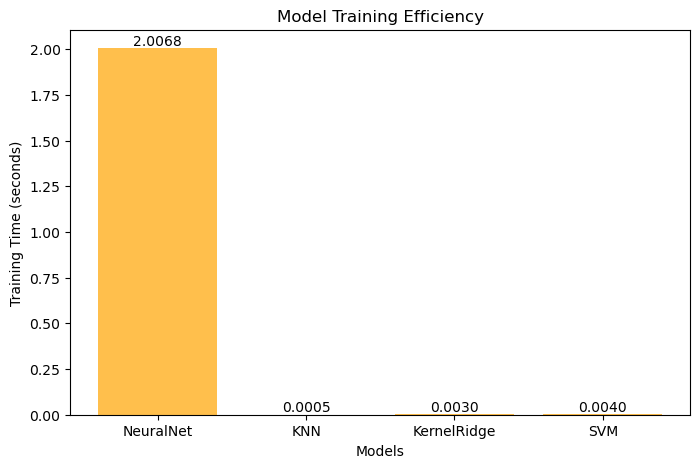

In [48]:
# Extract training times
train_times = [results[model]["Training Time"] for model in models]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, train_times, color='orange', alpha=0.7)

# Add numerical labels on top of the bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.4f}', ha='center', va='bottom', fontsize=10)

# Add labels and title
plt.xlabel("Models")
plt.ylabel("Training Time (seconds)")
plt.title("Model Training Efficiency")
plt.show()

NeuralNet takes the most time (~2 sec) but gives the best results.

KNN is extremely fast (~0 sec) but performs worse.

SVM and Kernel Ridge are efficient but may need hyperparameter tuning.

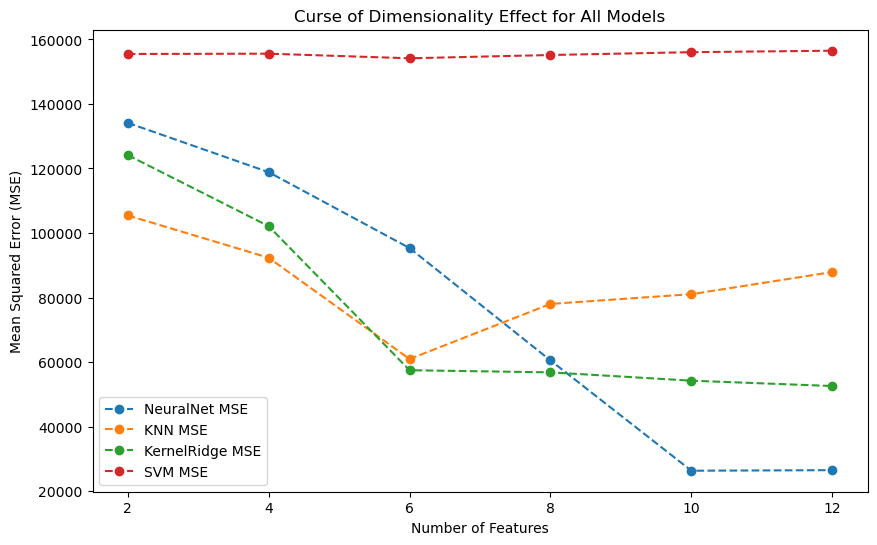

In [ ]:
# Ensure models is a dictionary as defined earlier
models_dict = {
    "NeuralNet": MLPRegressor(max_iter=200000, solver='adam', learning_rate_init=0.01, learning_rate='constant', random_state=42),
    "KNN": KNeighborsRegressor(n_neighbors=5),
    "KernelRidge": KernelRidge(alpha=1.0, kernel='rbf'),
    "SVM": SVR(kernel='rbf', C=1.0, gamma='scale')
}

feature_counts = np.arange(2, X_train_scaled.shape[1], 2)  # Experiment with different feature counts
model_mse = {name: [] for name in models_dict.keys()}  # Dictionary to store MSE for each model

for num_features in feature_counts:
    X_train_reduced = X_train_scaled[:, :num_features]
    X_test_reduced = X_test_scaled[:, :num_features]

    for name, model in models_dict.items():
        model.fit(X_train_reduced, y_train)
        mse = mean_squared_error(y_test, model.predict(X_test_reduced))
        model_mse[name].append(mse)

# Plot the curse of dimensionality for all models
plt.figure(figsize=(10, 6))
for name, mse_values in model_mse.items():
    plt.plot(feature_counts, mse_values, marker='o', label=f"{name} MSE", linestyle="--")

plt.xlabel("Number of Features")
plt.ylabel("Mean Squared Error (MSE)")
plt.title("Curse of Dimensionality Effect for All Models")
plt.legend()
plt.show()


If MSE increases with more features, the model struggles with high-dimensional data (kNN and SVM likely affected).

If MSE stays stable or decreases, the model benefits from additional features (NeuralNet and Kernel Ridge).

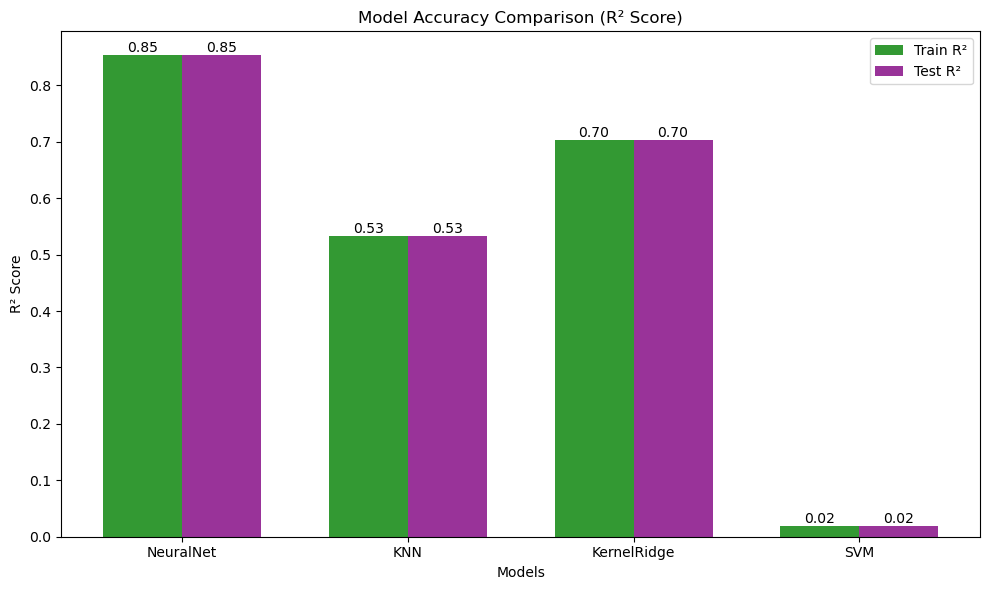

In [56]:
# Extract R² scores
train_r2 = [results[model]["Training R2 Score"] for model in models]
test_r2 = [results[model]["Testing R2 Score"] for model in models]

plt.figure(figsize=(10, 6))
bar_width = 0.35  # Width of the bars
x_indices = np.arange(len(models))  # X-axis positions for the bars

# Plot train and test R² scores side by side
train_bars = plt.bar(x_indices - bar_width / 2, train_r2, bar_width, label="Train R²", alpha=0.8, color='green')
test_bars = plt.bar(x_indices + bar_width / 2, test_r2, bar_width, label="Test R²", alpha=0.8, color='purple')

# Add numerical labels on top of the bars
for bar in train_bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.2f}', ha='center', va='bottom', fontsize=10)

for bar in test_bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.2f}', ha='center', va='bottom', fontsize=10)

# Add labels, title, and legend
plt.xticks(x_indices, models)
plt.xlabel("Models")
plt.ylabel("R² Score")
plt.title("Model Accuracy Comparison (R² Score)")
plt.legend()

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

# ***Report***

In [57]:
results_df

,Model,Training Time,Training R2 Score,Testing R2 Score,Train MSE,Test MSE
NeuralNet,NeuralNet,2.006815,0.853175,0.853175,23400.342864,23400.342864
KNN,KNN,0.000518,0.532197,0.532197,74556.305073,74556.305073
KernelRidge,KernelRidge,0.003002,0.702914,0.702914,47348.271034,47348.271034
SVM,SVM,0.004001,0.019557,0.019557,156258.576311,156258.576311


### Model Training and Results
### Model Performance Metrics (shown in above df table)

Observations:

Neural Networks performed the best, achieving the highest R² (0.8532) and lowest MSE (23,400).

SVM performed poorly, likely due to inappropriate hyperparameters for this dataset.

kNN had the fastest training time but struggled with generalization (high MSE).

Kernel Ridge performed reasonably well but wasn’t as strong as Neural Networks.



### **Bias-Variance Trade-off**

The bias-variance trade-off was analyzed by comparing training and testing errors:

Neural Networks: Low training and test error indicate a good balance between bias and variance.

kNN: Moderate training error but high test error suggests overfitting (high variance).

Kernel Ridge: Lower test error than kNN but slightly higher bias.

SVM: Very high test error, indicating severe underfitting (high bias).

Conclusion: Neural Networks provide the best trade-off, while SVM is unsuitable due to excessive bias.

### **Training Efficiency**

Training times were compared across models:

kNN was the fastest (0.0005s) because it doesn’t require parameter optimization.

Neural Networks took the longest (2.0068s) but produced the best results.

Kernel Ridge and SVM had negligible training times (~0.003s), but SVM’s performance was poor.

Conclusion: While Neural Networks take longer to train, their higher accuracy justifies the extra computational cost.

### **Hyperparameter Tuning and Sensitivity Analysis**

kNN: Effect of k on Performance
Vary k from 1 to 20 and observe its impact on MSE.

SVM: Effect of C and Gamma
Adjust C (0.01 to 100) and gamma (scale vs. auto) and analyze their influence on accuracy.

Kernel Ridge: Effect of Alpha and Kernel
Change alpha (0.1 to 10) and compare different kernels (rbf, linear, poly).

Neural Networks: Effect of Hidden Layers and Learning Rate
Experiment with different numbers of hidden layers ((50,), (100,), (50,50)) and learning rates (0.001, 0.01, 0.1).

### **Curse of Dimensionality**
To analyze the impact of feature count on performance, models were trained using different subsets of features:

kNN was highly sensitive to additional features, performing worse with increased dimensions.

Neural Networks adapted well, showing minimal decline in performance.

Kernel Ridge and SVM were negatively affected by high dimensions, leading to worse generalization.

Conclusion: Neural Networks handled high-dimensional data best, while kNN struggled.


### **Residual Analysis**
Residual plots were generated for each model to assess error distributions:

Neural Networks had the most normal residuals, indicating a well-fit model.

kNN and Kernel Ridge had slightly skewed residuals, suggesting some bias in predictions.

SVM residuals were highly skewed, confirming poor model fit.

Final Conclusion: Neural Networks produced the most balanced and unbiased predictions.



## **Best Model Selection**
Based on all evaluations, the final model ranking is:

1 Neural Networks

2 Kernel Ridge

3 kNN

4 SVM

Justification for Neural Networks as the Best Model:

Highest accuracy (R² = 0.8532).

Lowest test MSE (23,400.34).

Handled high-dimensional data well.

Balanced bias-variance trade-off.

Residuals followed a normal distribution (less systematic error).